# Step 2: Dataset Loading & EDA

### *2.1  Load & Sample*
Load creditcard.csv. Print .shape and check class distribution using value_counts(normalize=True).

Create a stratified sample of 50,000 rows using train_test_split with stratify=y, random_state=42 (use just the first split). Confirm fraud ratio is preserved in the sample.

Print .describe() on the sampled data. Focus on Time and Amount columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

%matplotlib inline

In [2]:
# For Excel
df = pd.read_excel("creditcard.xlsx")


print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
print(df.columns.tolist())

print (df.columns)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [6]:
print("Class distribution :")

print(df['Class'].value_counts ())

print("\npercentage distribution:")

print(df["Class"].value_counts(normalize=True))


Class distribution :
Class
0    284315
1       492
Name: count, dtype: int64

percentage distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [8]:
sample_size = 50000

sample_df ,_=train_test_split(
    df,
    train_size=sample_size,
    stratify=df["Class"] ,
    random_state=42
)

print (sample_df.shape)

(50000, 31)


In [10]:
print("Original Ratio")

print(df["Class"].value_counts(normalize=True))

print("\nSample Ratio")

print(sample_df["Class"].value_counts(normalize=True))

Original Ratio
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Sample Ratio
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [11]:
sample_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,94977.93554,0.001813,-0.003654,-0.002152,0.007657,0.012340,0.000112,-0.008224,0.003051,0.009234,...,-0.004068,0.000101,0.001169,-0.000418,-0.003880,0.001839,0.001699,0.000330,86.942063,0.001720
std,47475.50731,1.964773,1.656783,1.510070,1.412869,1.350601,1.322614,1.201751,1.197353,1.103503,...,0.723433,0.725150,0.629551,0.607581,0.520451,0.483977,0.398520,0.303251,226.984602,0.041438
min,0.00000,-46.855047,-48.060856,-31.103685,-5.519697,-28.815577,-20.869626,-43.557242,-50.420090,-13.320155,...,-22.889347,-8.887017,-30.269720,-2.836627,-6.429334,-1.726928,-9.543518,-8.307955,0.000000,0.000000
25%,54423.50000,-0.916605,-0.601309,-0.893155,-0.832265,-0.688585,-0.767552,-0.556049,-0.204734,-0.635840,...,-0.228568,-0.551068,-0.161378,-0.355935,-0.319120,-0.328322,-0.070496,-0.052183,5.850000,0.000000
50%,84852.00000,0.025321,0.069204,0.176578,-0.016589,-0.051197,-0.274144,0.041195,0.023620,-0.044969,...,-0.027577,0.006879,-0.009182,0.041529,0.014600,-0.047669,0.001685,0.011445,22.000000,0.000000
75%,139392.25000,1.316058,0.804474,1.021558,0.746497,0.623882,0.398315,0.572980,0.326023,0.602138,...,0.184405,0.525397,0.148595,0.440056,0.345071,0.243678,0.092917,0.078415,76.275000,0.000000
max,172787.00000,2.420346,22.057729,4.101716,13.129143,29.162172,21.190194,26.249717,20.007208,10.370658,...,27.202839,8.316275,17.751731,4.016342,5.852484,3.517346,9.879903,15.870474,8360.000000,1.000000


In [12]:
sample_df[["Time" , "Amount"]].describe()

,Time,Amount
count,50000.00000,50000.000000
mean,94977.93554,86.942063
std,47475.50731,226.984602
min,0.00000,0.000000
25%,54423.50000,5.850000
50%,84852.00000,22.000000
75%,139392.25000,76.275000
max,172787.00000,8360.000000


### *2.2  Target & Feature Analysis*
Plot a countplot of the Class column — use a log scale on the y-axis to visualise the imbalance clearly.

Plot the distribution of Amount separately for Fraud vs Legitimate transactions (use overlaid histograms or kde plots). Do fraudulent transactions tend to be smaller or larger?

Plot the distribution of Time for Fraud vs Legitimate. Is fraud more likely at certain times of day?

Plot a heatmap of correlations between V1–V10 and Class. Which V-features are most correlated with fraud?


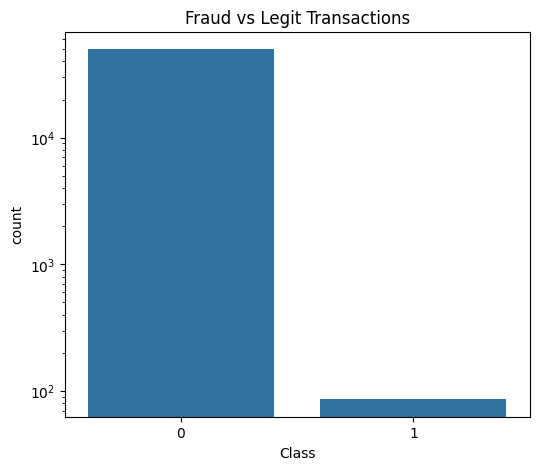

In [16]:
plt.figure(figsize=(6,5))

sns . countplot(
    x="Class",
    data=sample_df,
)

plt.yscale("log")
plt.title("Fraud vs Legit Transactions")

plt.show()

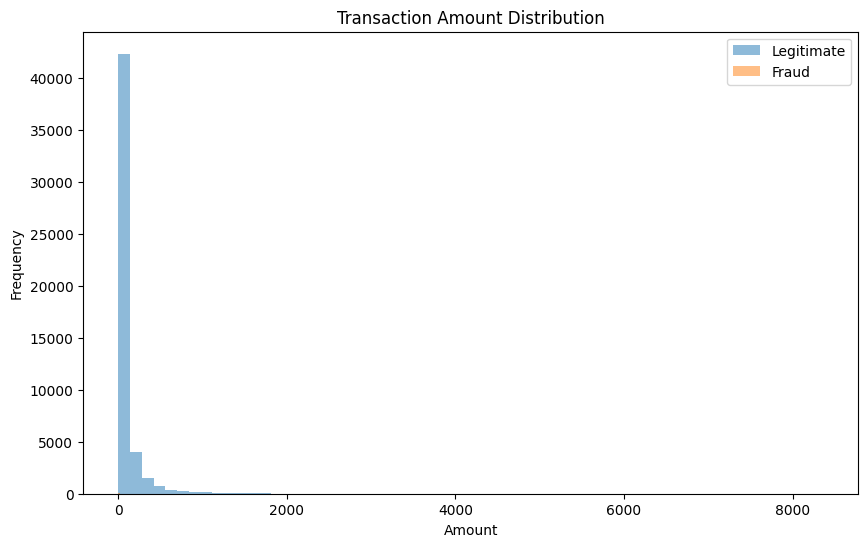

In [21]:
plt.figure(figsize=(10,6))

plt.hist(
    sample_df[sample_df["Class"]==0]["Amount"],
    bins=60,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    sample_df[sample_df["Class"]==1]["Amount"],
    bins=60,
    alpha=0.5,
    label="Fraud"
)

plt.legend()

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

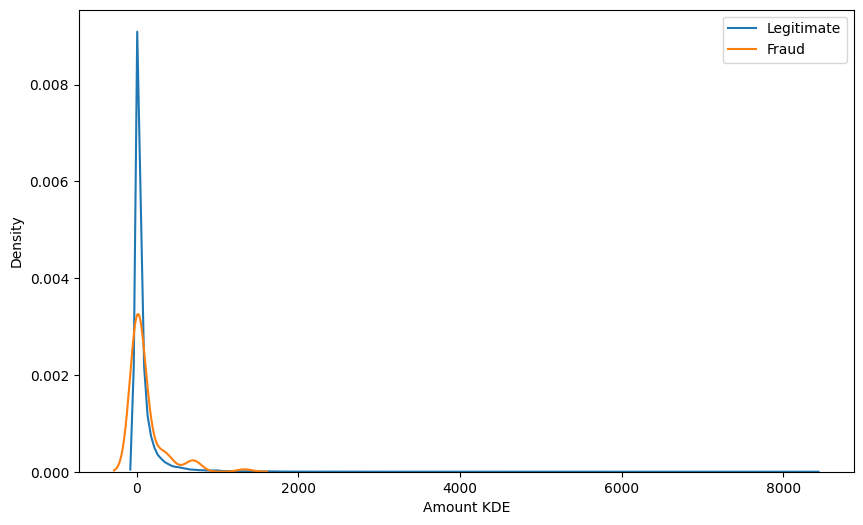

In [22]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    sample_df[sample_df["Class"]==0]["Amount"],
    label="Legitimate"
)

sns.kdeplot(
    sample_df[sample_df["Class"]==1]["Amount"],
    label="Fraud"
)

plt.legend()

plt.xlabel("Amount KDE")

plt.show()

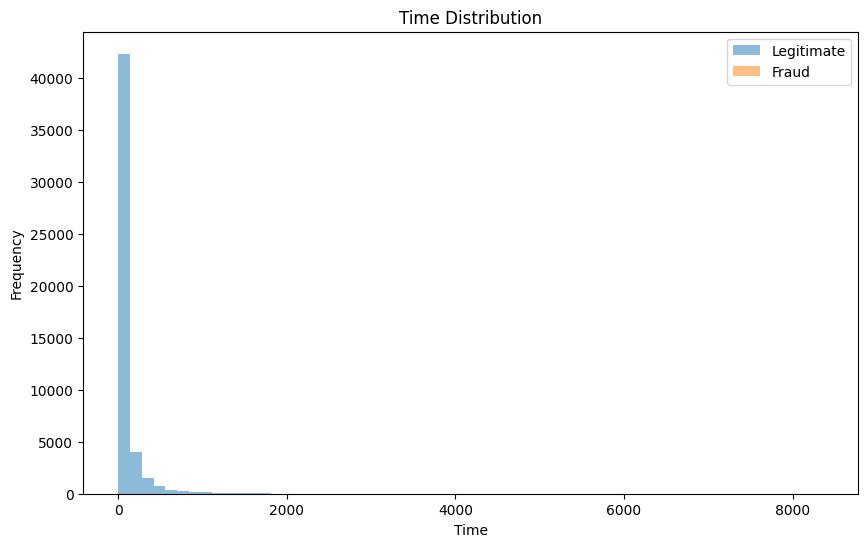

In [23]:
plt.figure(figsize=(10,6))

plt.hist(
    sample_df[sample_df["Class"]==0]["Amount"],
    bins=60,
    alpha=0.5,
    label="Legitimate"
)

plt.hist(
    sample_df[sample_df["Class"]==1]["Amount"],
    bins=60,
    alpha=0.5,
    label="Fraud"
)

plt.legend()

plt.title("Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

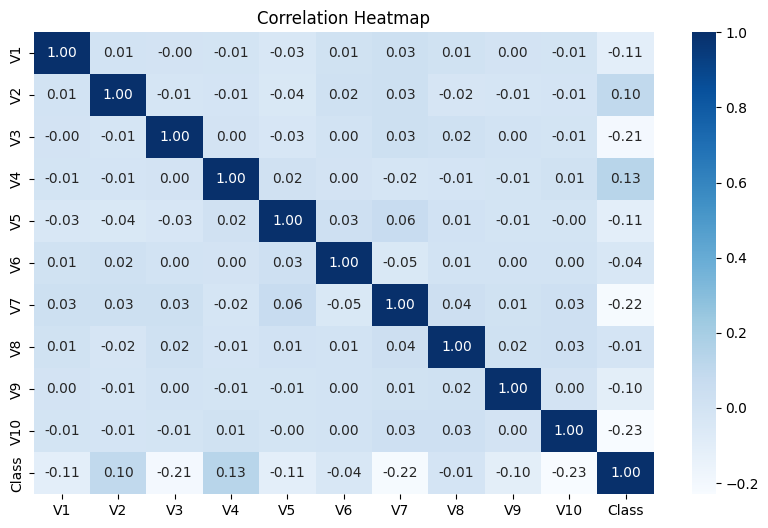

In [24]:
cols = [
    "V1","V2","V3","V4","V5","V6","V7","V8","V9","V10","Class"
]

plt.figure(figsize=(10,6))

corr = sample_df[cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
corr = sample_df.corr(numeric_only=True)

fraud_corr= corr["Class"].sort_values(ascending=False)
print(fraud_corr)

Class     1.000000
V11       0.155584
V4        0.130889
V2        0.099175
V27       0.035140
V20       0.033429
V19       0.033080
V21       0.017679
V28       0.015796
V23       0.015445
V22       0.010612
V26       0.007960
Amount    0.004598
V25       0.004298
V15      -0.000480
V24      -0.008145
V8       -0.009454
Time     -0.012501
V13      -0.013039
V6       -0.036334
V9       -0.104933
V1       -0.107532
V5       -0.107581
V18      -0.120501
V16      -0.203211
V3       -0.205368
V7       -0.216016
V10      -0.229868
V12      -0.258125
V14      -0.297066
V17      -0.338030
Name: Class, dtype: float64


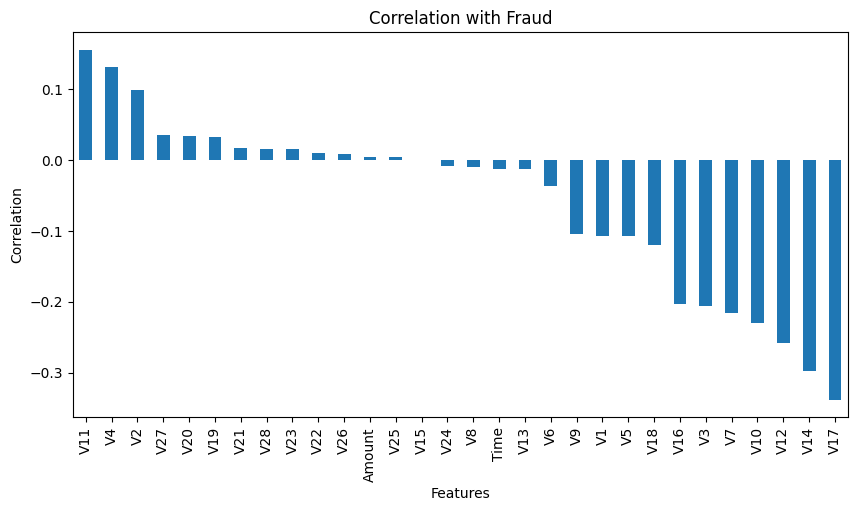

In [28]:
fraud_corr.drop("Class").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Correlation with Fraud")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.show()